In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from diffusion_model import DiffusionModel, TransformerPositionalEmbedding

In [2]:
def bvc_to_bchw(tensor, H=200, W=200):
    """
    Convert [B, V, C] -> [B, C, H, W].
    Accepts torch.Tensor or numpy.ndarray. If H and W don't match V, will try to infer square side.
    """
    B, V, C = tensor.shape
    if V != H*W:
        raise ValueError(f"H and W are not product from V, please specify what H and W you want")
    
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, H, W, C)
        tensor = tensor.permute(0, 3, 2, 1).contiguous()
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, H, W, C)
        tensor = np.transpose(tensor, (0, 3, 2, 1))
        return tensor
    else:
        raise TypeError("Expected torch.TEnsor or numpy.ndarray")
    
def bchw_to_bvc(tensor):
    """
    Convert [B, C, H, W] -> [B, V, C] where V = H*W.
    Accepts torch.Tensor or numpy.ndarray.
    """
    B, C, H, W = tensor.shape
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.reshape(B, C, H*W)
        tensor = tensor.permute(0, 2, 1).contiguous()  
        return tensor
    elif isinstance(tensor, np.ndarray):
        tensor = tensor.copy()
        tensor = tensor.reshape(B, C, H*W)
        tensor = np.transpose(tensor, (0, 2, 1))
        return tensor


In [3]:
all_img_bev = torch.load('/home/mingdayang/mmdetection3d/mapping_test/all_img_bev.pt')
all_pts_bev = torch.load('/home/mingdayang/mmdetection3d/mapping_test/all_pts_bev.pt')
print(all_img_bev.keys())

dict_keys(['img_bev_embed', 'lidar_file_name'])


In [4]:
img_bev_embed = bvc_to_bchw(all_img_bev['img_bev_embed'])
pts_bev_embed = bvc_to_bchw(all_pts_bev['pts_bev_embed'])
X = img_bev_embed.cpu().numpy()
Y = pts_bev_embed.cpu().numpy()

In [5]:
diffusion = DiffusionModel(unet_model=None, timesteps=1000, beta_start=0.0001, beta_end=0.02)

torch.Size([256, 200, 200])


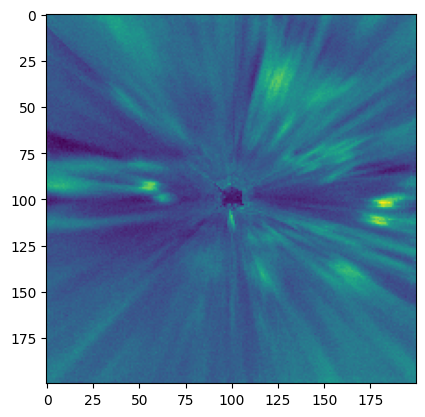

In [6]:
noise_img = diffusion.forward_diffusion(img_bev_embed[0], t=1)
print(noise_img.shape)
plt.imshow(noise_img.mean(dim=0).cpu().numpy())

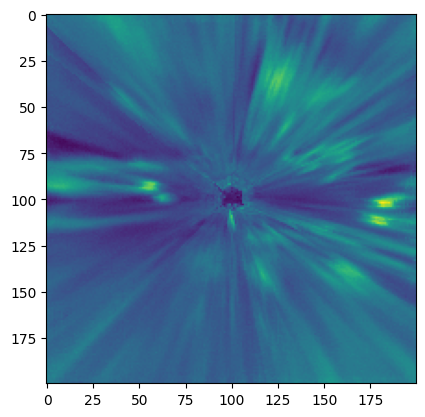

In [7]:

denoise_img = diffusion.reverse_diffusion(noise_img, diffusion.noise, 1)
plt.imshow(denoise_img.mean(dim=0).cpu().numpy())

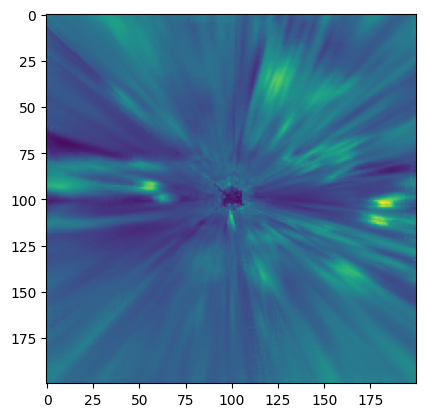

In [8]:
plt.imshow(img_bev_embed[0].mean(dim=0).cpu().numpy())

In [9]:
t = torch.randint(0, 1000, (X.shape[0],))
print(t.shape)
print(t)

torch.Size([81])
tensor([ 78, 821, 589, 945, 609, 234, 250, 978, 356, 201, 324, 878, 248, 234,
        871, 675, 413, 378, 402,  64, 223, 619, 439, 451, 340, 597, 909, 680,
        713, 847, 508, 826, 650,  20, 404, 463, 169, 829, 217, 675, 942, 749,
         10, 614,  85, 413, 171, 530, 691, 329, 691, 713, 183, 640, 122,  74,
        866, 310, 118, 645, 548, 855, 546, 863, 325,  44, 130, 404, 711, 357,
        309, 431, 773, 832, 208, 224, 845,  74, 136, 963, 983])


In [14]:
a = TransformerPositionalEmbedding(256, 1000)
poss_embed  = a(t)

In [15]:
print(poss_embed.shape)

torch.Size([81, 256])


In [16]:
class TransformerPositionalEmbedding(nn.Module):
    """
    From paper "Attention Is All You Need", section 3.5
    """
    def __init__(self, dimension, max_timesteps=1000):
        super(TransformerPositionalEmbedding, self).__init__()
        assert dimension % 2 == 0, "Embedding dimension must be even"
        self.dimension = dimension
        self.pe_matrix = torch.zeros(max_timesteps, dimension)
        # Gather all the even dimensions across the embedding vector
        even_indices = torch.arange(0, self.dimension, 2)
        # Calculate the term using log transforms for faster calculations
        # (https://stackoverflow.com/questions/17891595/pow-vs-exp-performance)
        log_term = torch.log(torch.tensor(10000.0)) / self.dimension
        div_term = torch.exp(even_indices * -log_term)

        # Precompute positional encoding matrix based on odd/even timesteps
        timesteps = torch.arange(max_timesteps).unsqueeze(1)
        self.pe_matrix[:, 0::2] = torch.sin(timesteps * div_term)
        self.pe_matrix[:, 1::2] = torch.cos(timesteps * div_term)

    def forward(self, timestep):
        # [bs, d_model]
        return self.pe_matrix[timestep].to(timestep.device)


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, groups=8):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm = nn.GroupNorm(groups, out_channels)
        self.act = nn.SiLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.norm(x)
        x = self.act(x)
        return x


class DownsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, padding):
        super(DownsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=padding)

    def forward(self, input_tensor):
        x = self.conv(input_tensor)
        return x


class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, scale_factor=2.0):
        super(UpsampleBlock, self).__init__()

        self.scale = scale_factor
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)

    def forward(self, input_tensor):
        # align_corners=True for potential convertibility to ONNX
        x = F.interpolate(input_tensor, scale_factor=self.scale, mode="bilinear", align_corners=True)
        x = self.conv(x)
        return x


class ConvDownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_layers, time_emb_channels, num_groups, downsample=True):
        super(ConvDownBlock, self).__init__()
        resnet_blocks = []
        for i in range(num_layers):
            in_channels = in_channels if i == 0 else out_channels
            resnet_block = ResNetBlock(in_channels=in_channels,
                                       out_channels=out_channels,
                                       time_emb_channels=time_emb_channels,
                                       num_groups=num_groups)
            resnet_blocks.append(resnet_block)

        self.resnet_blocks = nn.ModuleList(resnet_blocks)

        self.downsample = DownsampleBlock(in_channels=out_channels, out_channels=out_channels, stride=2, padding=1) \
            if downsample \
            else None

    def forward(self, input_tensor, time_embedding):
        x = input_tensor
        for resnet_block in self.resnet_blocks:
            x = resnet_block(x, time_embedding)
        if self.downsample:
            x = self.downsample(x)
        return x


class ConvUpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_layers, time_emb_channels, num_groups, upsample=True):
        super(ConvUpBlock, self).__init__()
        resnet_blocks = []
        for i in range(num_layers):
            in_channels = in_channels if i == 0 else out_channels
            resnet_block = ResNetBlock(in_channels=in_channels,
                                       out_channels=out_channels,
                                       time_emb_channels=time_emb_channels,
                                       num_groups=num_groups)
            resnet_blocks.append(resnet_block)

        self.resnet_blocks = nn.ModuleList(resnet_blocks)

        self.upsample = UpsampleBlock(in_channels=out_channels, out_channels=out_channels) \
            if upsample \
            else None

    def forward(self, input_tensor, time_embedding):
        x = input_tensor
        for resnet_block in self.resnet_blocks:
            x = resnet_block(x, time_embedding)
        if self.upsample:
            x = self.upsample(x)
        return x


class SelfAttentionBlock(nn.Module):
    """
    Self-attention blocks are applied at the 16x16 resolution in the original DDPM paper.
    Implementation is based on "Attention Is All You Need" paper, Vaswani et al., 2015
    (https://arxiv.org/pdf/1706.03762.pdf)
    """
    def __init__(self, num_heads, in_channels, num_groups=32, embedding_dim=256):
        super(SelfAttentionBlock, self).__init__()
        # For each of heads use d_k = d_v = d_model / num_heads
        self.num_heads = num_heads
        self.d_model = embedding_dim
        self.d_keys = embedding_dim // num_heads
        self.d_values = embedding_dim // num_heads

        self.query_projection = nn.Linear(in_channels, embedding_dim)
        self.key_projection = nn.Linear(in_channels, embedding_dim)
        self.value_projection = nn.Linear(in_channels, embedding_dim)

        self.final_projection = nn.Linear(embedding_dim, embedding_dim)
        self.norm = nn.GroupNorm(num_channels=embedding_dim, num_groups=num_groups)

    def split_features_for_heads(self, tensor):
        # We receive Q, K and V at shape [batch, h*w, embedding_dim].
        # This method splits embedding_dim into 'num_heads' features so that
        # each channel becomes of size embedding_dim / num_heads.
        # Output shape becomes [batch, num_heads, h*w, embedding_dim/num_heads],
        # where 'embedding_dim/num_heads' is equal to d_k = d_k = d_v = sizes for
        # K, Q and V respectively, according to paper.
        batch, hw, emb_dim = tensor.shape
        channels_per_head = emb_dim // self.num_heads
        heads_splitted_tensor = torch.split(tensor, split_size_or_sections=channels_per_head, dim=-1)
        heads_splitted_tensor = torch.stack(heads_splitted_tensor, 1)
        return heads_splitted_tensor

    def forward(self, input_tensor):
        x = input_tensor
        batch, features, h, w = x.shape
        # Do reshape and transpose input tensor since we want to process depth feature maps, not spatial maps
        x = x.view(batch, features, h * w).transpose(1, 2)

        # Get linear projections of K, Q and V according to Fig. 2 in the original Transformer paper
        queries = self.query_projection(x)  # [b, in_channels, embedding_dim]
        keys = self.key_projection(x)       # [b, in_channels, embedding_dim]
        values = self.value_projection(x)   # [b, in_channels, embedding_dim]

        # Split Q, K, V between attention heads to process them simultaneously
        queries = self.split_features_for_heads(queries)
        keys = self.split_features_for_heads(keys)
        values = self.split_features_for_heads(values)

        # Perform Scaled Dot-Product Attention (eq. 1 in the Transformer paper).
        # Each SDPA block yields tensor of size d_v = embedding_dim/num_heads.
        scale = self.d_keys ** -0.5
        attention_scores = torch.softmax(torch.matmul(queries, keys.transpose(-1, -2)) * scale, dim=-1)
        attention_scores = torch.matmul(attention_scores, values)

        # Permute computed attention scores such that
        # [batch, num_heads, h*w, embedding_dim] --> [batch, h*w, num_heads, d_v]
        attention_scores = attention_scores.permute(0, 2, 1, 3).contiguous()

        # Concatenate scores per head into one tensor so that
        # [batch, h*w, num_heads, d_v] --> [batch, h*w, num_heads*d_v]
        concatenated_heads_attention_scores = attention_scores.view(batch, h * w, self.d_model)

        # Perform linear projection and reshape tensor such that
        # [batch, h*w, d_model] --> [batch, d_model, h*w] -> [batch, d_model, h, w]
        linear_projection = self.final_projection(concatenated_heads_attention_scores)
        linear_projection = linear_projection.transpose(-1, -2).reshape(batch, self.d_model, h, w)

        # Residual connection + norm
        x = self.norm(linear_projection + input_tensor)
        return x


class AttentionDownBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 num_layers,
                 time_emb_channels,
                 num_groups,
                 num_att_heads,
                 downsample=True):
        """
        AttentionDownBlock consists of ResNet blocks with Self-Attention blocks in-between
        :param in_channels:
        :param out_channels:
        :param num_layers:
        :param time_emb_channels:
        :param num_groups:
        :param num_att_heads:
        :param downsample:
        """
        super(AttentionDownBlock, self).__init__()

        resnet_blocks = []
        attention_blocks = []
        for i in range(num_layers):
            in_channels = in_channels if i == 0 else out_channels
            resnet_block = ResNetBlock(in_channels=in_channels,
                                       out_channels=out_channels,
                                       time_emb_channels=time_emb_channels,
                                       num_groups=num_groups)
            attention_block = SelfAttentionBlock(in_channels=out_channels,
                                                 embedding_dim=out_channels,
                                                 num_heads=num_att_heads,
                                                 num_groups=num_groups)

            resnet_blocks.append(resnet_block)
            attention_blocks.append(attention_block)

        self.resnet_blocks = nn.ModuleList(resnet_blocks)
        self.attention_blocks = nn.ModuleList(attention_blocks)

        self.downsample = DownsampleBlock(in_channels=out_channels, out_channels=out_channels, stride=2, padding=1) \
            if downsample \
            else None

    def forward(self, input_tensor, time_embedding):
        x = input_tensor
        for resnet_block, attention_block in zip(self.resnet_blocks, self.attention_blocks):
            x = resnet_block(x, time_embedding)
            x = attention_block(x)
        if self.downsample:
            x = self.downsample(x)
        return x


class AttentionUpBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 num_layers,
                 time_emb_channels,
                 num_groups,
                 num_att_heads,
                 upsample=True):
        """
        :param in_channels:
        :param out_channels:
        :param num_layers:
        :param time_emb_channels:
        :param num_groups:
        :param num_att_heads:
        :param upsample:
        """
        super(AttentionUpBlock, self).__init__()

        resnet_blocks = []
        attention_blocks = []
        for i in range(num_layers):
            in_channels = in_channels if i == 0 else out_channels
            resnet_block = ResNetBlock(in_channels=in_channels,
                                       out_channels=out_channels,
                                       time_emb_channels=time_emb_channels,
                                       num_groups=num_groups)
            attention_block = SelfAttentionBlock(in_channels=out_channels,
                                                 embedding_dim=out_channels,
                                                 num_heads=num_att_heads,
                                                 num_groups=num_groups)

            resnet_blocks.append(resnet_block)
            attention_blocks.append(attention_block)

        self.resnet_blocks = nn.ModuleList(resnet_blocks)
        self.attention_blocks = nn.ModuleList(attention_blocks)

        self.upsample = UpsampleBlock(in_channels=out_channels, out_channels=out_channels) \
            if upsample \
            else None

    def forward(self, input_tensor, time_embedding):
        x = input_tensor
        for resnet_block, attention_block in zip(self.resnet_blocks, self.attention_blocks):
            x = resnet_block(x, time_embedding)
            x = attention_block(x)
        if self.upsample:
            x = self.upsample(x)
        return x


class ResNetBlock(nn.Module):
    """
    In the original DDPM paper Wide ResNet was used
    (https://arxiv.org/pdf/1605.07146.pdf).
    """
    def __init__(self, in_channels, out_channels, *, time_emb_channels=None, num_groups=8):
        super(ResNetBlock, self).__init__()
        self.time_embedding_projectile = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_channels, out_channels))
            if time_emb_channels
            else None
        )

        self.block1 = ConvBlock(in_channels, out_channels, groups=num_groups)
        self.block2 = ConvBlock(out_channels, out_channels, groups=num_groups)
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_embedding=None):
        input_tensor = x
        h = self.block1(x)
        # According to authors implementations, they inject timestep embedding into the network
        # using MLP after the first conv block in all the ResNet blocks
        # (https://github.com/hojonathanho/diffusion/blob/1e0dceb3b3495bbe19116a5e1b3596cd0706c543/diffusion_tf/models/unet.py#L49)

        time_emb = self.time_embedding_projectile(time_embedding)
        time_emb = time_emb[:, :, None, None]
        x = time_emb + h

        x = self.block2(x)
        return x + self.residual_conv(input_tensor)

class UNet(nn.Module):
    """
    Model architecture as described in the DDPM paper, Appendix, section B
    """

    def __init__(self, image_size=256, input_channels=3):
        super().__init__()
        # 1. We replaced weight normalization with group normalization
        # 2. Our 32x32 models use four feature map resolutions (32x32 to 4x4), and our 256x256 models use six (I made 5)
        # 3. Two convolutional residual blocks per resolution level and self-attention blocks at the 16x16 resolution
        # between the convolutional blocks [https://arxiv.org/pdf/1712.09763.pdf]
        # 4. Diffusion time t is specified by adding the Transformer sinusoidal position embedding into
        # each residual block [https://arxiv.org/pdf/1706.03762.pdf]

        self.initial_conv = nn.Conv2d(in_channels=input_channels, out_channels=128, kernel_size=3, stride=1, padding='same')
        self.positional_encoding = nn.Sequential(
            TransformerPositionalEmbedding(dimension=128),
            nn.Linear(128, 128 * 4),
            nn.GELU(),
            nn.Linear(128 * 4, 128 * 4)
        )

        self.downsample_blocks = nn.ModuleList([
            ConvDownBlock(in_channels=128, out_channels=128, num_layers=2, num_groups=32, time_emb_channels=128 * 4),
            ConvDownBlock(in_channels=128, out_channels=128, num_layers=2, num_groups=32, time_emb_channels=128 * 4),
            ConvDownBlock(in_channels=128, out_channels=256, num_layers=2, num_groups=32, time_emb_channels=128 * 4),
            AttentionDownBlock(in_channels=256, out_channels=256, num_layers=2, num_att_heads=4, num_groups=32, time_emb_channels=128 * 4),
            ConvDownBlock(in_channels=256, out_channels=512, num_layers=2, num_groups=32, time_emb_channels=128 * 4)
        ])

        self.bottleneck = AttentionDownBlock(in_channels=512, out_channels=512, num_layers=2, num_att_heads=4, num_groups=32, time_emb_channels=128*4, downsample=False)                                                                                                  # 16x16x256 -> 16x16x256

        self.upsample_blocks = nn.ModuleList([
            ConvUpBlock(in_channels=512 + 512, out_channels=512, num_layers=2, num_groups=32, time_emb_channels=128 * 4),
            AttentionUpBlock(in_channels=512 + 256, out_channels=256, num_layers=2, num_att_heads=4, num_groups=32, time_emb_channels=128 * 4),
            ConvUpBlock(in_channels=256 + 256, out_channels=256, num_layers=2, num_groups=32, time_emb_channels=128 * 4),
            ConvUpBlock(in_channels=256 + 128, out_channels=128, num_layers=2, num_groups=32, time_emb_channels=128 * 4),
            ConvUpBlock(in_channels=128 + 128, out_channels=128, num_layers=2, num_groups=32, time_emb_channels=128 * 4)
        ])

        self.output_conv = nn.Sequential(
            nn.GroupNorm(num_channels=256, num_groups=32),
            nn.SiLU(),
            nn.Conv2d(256, 3, 3, padding=1)
        )

    def forward(self, input_tensor, time):
        time_encoded = self.positional_encoding(time)

        initial_x = self.initial_conv(input_tensor)

        states_for_skip_connections = [initial_x]

        x = initial_x
        for i, block in enumerate(self.downsample_blocks):
            x = block(x, time_encoded)
            states_for_skip_connections.append(x)
        states_for_skip_connections = list(reversed(states_for_skip_connections))

        x = self.bottleneck(x, time_encoded)

        for i, (block, skip) in enumerate(zip(self.upsample_blocks, states_for_skip_connections)):
            x = torch.cat([x, skip], dim=1)
            x = block(x, time_encoded)

        # Concat initial_conv with tensor
        x = torch.cat([x, states_for_skip_connections[-1]], dim=1)
        # Get initial shape [3, 256, 256] with convolutions
        out = self.output_conv(x)

        return out